<a id="#section-one"></a>
# 1. Introduction
In this final assignment, I will use a dataset from a survey held by NHANES in 2015-2016. I collected the dataset from kaggle. I will conduct descriptive and diagnostic analysis with the aim to collect and compare data of BMI in different age group and gender. 

This dataset consists of 28 columns and 5735 rows. Among 28 columns, I isolated some columns which are related to my analysis. 

Brief explanation of the column :

* SEQN = Respondent sequence number (
* SMQ020 = Smoking 
* RIAGENDR = Gender 
* RIDAGEYR = Age (years)
* DMDEDUC2 = Education level
* BMXWT  = Weight (kg)
* BMXHT = Height (cm)
* BMXBMI = BMI

# 2. Retrieving Data

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
da =pd.read_csv('NHANES.csv')

In [92]:
da.head()

,SEQN,ALQ101,ALQ110,ALQ130,SMQ020,RIAGENDR,RIDAGEYR,RIDRETH1,DMDCITZN,DMDEDUC2,...,BPXSY2,BPXDI2,BMXWT,BMXHT,BMXBMI,BMXLEG,BMXARML,BMXARMC,BMXWAIST,HIQ210
0,83732,1.0,NaN,1.0,1,1,62,3,1.0,5.0,...,124.0,64.0,94.8,184.5,27.8,43.3,43.6,35.9,101.1,2.0
1,83733,1.0,NaN,6.0,1,1,53,3,2.0,3.0,...,140.0,88.0,90.4,171.4,30.8,38.0,40.0,33.2,107.9,NaN
2,83734,1.0,NaN,NaN,1,1,78,3,1.0,3.0,...,132.0,44.0,83.4,170.1,28.8,35.6,37.0,31.0,116.5,2.0
3,83735,2.0,1.0,1.0,2,2,56,3,1.0,5.0,...,134.0,68.0,109.8,160.9,42.4,38.5,37.7,38.3,110.1,2.0
4,83736,2.0,1.0,1.0,2,2,42,4,1.0,4.0,...,114.0,54.0,55.2,164.9,20.3,37.4,36.0,27.2,80.4,2.0


In [93]:
da.shape

(5735, 28)

In [94]:
da.columns

Index(['SEQN', 'ALQ101', 'ALQ110', 'ALQ130', 'SMQ020', 'RIAGENDR', 'RIDAGEYR',
       'RIDRETH1', 'DMDCITZN', 'DMDEDUC2', 'DMDMARTL', 'DMDHHSIZ', 'WTINT2YR',
       'SDMVPSU', 'SDMVSTRA', 'INDFMPIR', 'BPXSY1', 'BPXDI1', 'BPXSY2',
       'BPXDI2', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXLEG', 'BMXARML', 'BMXARMC',
       'BMXWAIST', 'HIQ210'],
      dtype='object')

In [95]:
da[['SEQN','SMQ020', 'RIAGENDR', 'RIDAGEYR','DMDEDUC2','BMXWT', 'BMXHT', 'BMXBMI']]

,SEQN,SMQ020,RIAGENDR,RIDAGEYR,DMDEDUC2,BMXWT,BMXHT,BMXBMI
0,83732,1,1,62,5.0,94.8,184.5,27.8
1,83733,1,1,53,3.0,90.4,171.4,30.8
2,83734,1,1,78,3.0,83.4,170.1,28.8
3,83735,2,2,56,5.0,109.8,160.9,42.4
4,83736,2,2,42,4.0,55.2,164.9,20.3
...,...,...,...,...,...,...,...,...
5730,93695,1,2,76,3.0,59.1,165.8,21.5
5731,93696,2,1,26,5.0,112.1,182.2,33.8
5732,93697,1,2,80,4.0,71.7,152.2,31.0
5733,93700,1,1,35,1.0,78.2,173.3,26.0


In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5406 entries, 0 to 5734
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   seqn       5406 non-null   int64  
 1   smoking    5406 non-null   int64  
 2   gender     5406 non-null   int64  
 3   age        5406 non-null   int64  
 4   education  5406 non-null   float64
 5   weight     5406 non-null   float64
 6   hAght      5406 non-null   float64
 7   bmi        5406 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 380.1 KB


In [97]:
# Change the column names to ease the use
data.columns = ['seqn','smoking','gender', 'age','education','weight','hAght','bmi']

In [98]:
data.head()

,seqn,smoking,gender,age,education,weight,hAght,bmi
0,83732,1,1,62,5.0,94.8,184.5,27.8
1,83733,1,1,53,3.0,90.4,171.4,30.8
2,83734,1,1,78,3.0,83.4,170.1,28.8
3,83735,2,2,56,5.0,109.8,160.9,42.4
4,83736,2,2,42,4.0,55.2,164.9,20.3


In [99]:
data.shape

(5406, 8)

<a id="#section-three"></a>
# 3. Data Cleaning

Steps I will use in data cleaning :

1. Check for duplicate or unnecessary data
2.Check for null values or missing data
3. Check for outliers


In [100]:
# Check for duplicates
duplicateRowsDF = data[data.duplicated()]
duplicateRowsDF

,seqn,smoking,gender,age,education,weight,hAght,bmi


There is no duplicate data in this dataset, so I will can drop the 'seqn' column because every row contains unique data so it doesn't give much explanation about the data. 

In [105]:
data.drop(columns = 'SEQN', inplace = True)

KeyError: "['SEQN'] not found in axis"

In [ ]:
data.head(10)

,SMQ020,RIAGENDR,RIDAGEYR,DMDEDUC2,BMXWT,BMXHT,BMXBMI
0,1,1,62,5.0,94.8,184.5,27.8
1,1,1,53,3.0,90.4,171.4,30.8
2,1,1,78,3.0,83.4,170.1,28.8
3,2,2,56,5.0,109.8,160.9,42.4
4,2,2,42,4.0,55.2,164.9,20.3
5,2,2,72,2.0,64.4,150.0,28.6
6,1,1,22,4.0,76.6,165.4,28.0
7,2,2,32,4.0,64.5,151.3,28.2
8,2,1,18,NaN,72.4,166.1,26.2
9,2,1,56,3.0,108.3,179.4,33.6


#### 3.2 Check for missing values and handle them

In [ ]:
data.duplicated().sum()

np.int64(0)

I have missing values in column education, weight, height, and bmi. For education, I think it is better to drop them because filling the missed value might mislead the real data. For weight, height and bmi, I will drop them too because the number of missing values are very small compared to the dataset (>5000 rows).

In [ ]:
data.shape

(5735, 7)

In [ ]:
data.dropna(inplace=True)

#### 3.3 Find outliers and handle outliers

I have three numerical data (weight, height and bmi), so I will try to find outliers from these columns using histogram and boxplot.

In [106]:
# Descriptive analysis of numerical data
numerical = ['age','weight','hAght','bmi']
data[numerical].describe()

,age,weight,hAght,bmi
count,5406.000000,5406.000000,5406.000000,5406.000000
mean,49.390122,81.715594,166.055679,29.541861
std,17.640915,21.775173,10.107149,7.076574
min,20.000000,32.400000,129.700000,14.500000
25%,34.000000,66.300000,158.600000,24.500000
50%,49.000000,78.500000,165.900000,28.500000
75%,64.000000,93.200000,173.400000,33.200000
max,80.000000,198.900000,202.700000,67.300000


In [ ]:
# Check for missing data
data.isnull().sum()

SMQ020        0
RIAGENDR      0
RIDAGEYR      0
DMDEDUC2    261
BMXWT        69
BMXHT        62
BMXBMI       73
dtype: int64

I have missing values in column education, weight, height, and bmi. For education, I think it is better to drop them because filling the missed value might mislead the real data. For weight, height and bmi, I will drop them too because the number of missing values are very small compared to the dataset (>5000 rows).

In [ ]:
# Dataset before handling missing values
data.shape

(5735, 7)

In [ ]:
# Drop the missing values
data.dropna(inplace = True)

In [ ]:
#Dataset after missing values are dropped
data.shape

(5406, 7)

#### 3.3 Find outliers and handle outliers

I have three numerical data (weight, height and bmi), so I will try to find outliers from these columns using histogram and boxplot.

In [108]:
# Descriptive analysis of numerical data
numerical = ['age','weight','hAght','bmi']
data[numerical].describe()

,age,weight,hAght,bmi
count,5406.000000,5406.000000,5406.000000,5406.000000
mean,49.390122,81.715594,166.055679,29.541861
std,17.640915,21.775173,10.107149,7.076574
min,20.000000,32.400000,129.700000,14.500000
25%,34.000000,66.300000,158.600000,24.500000
50%,49.000000,78.500000,165.900000,28.500000
75%,64.000000,93.200000,173.400000,33.200000
max,80.000000,198.900000,202.700000,67.300000


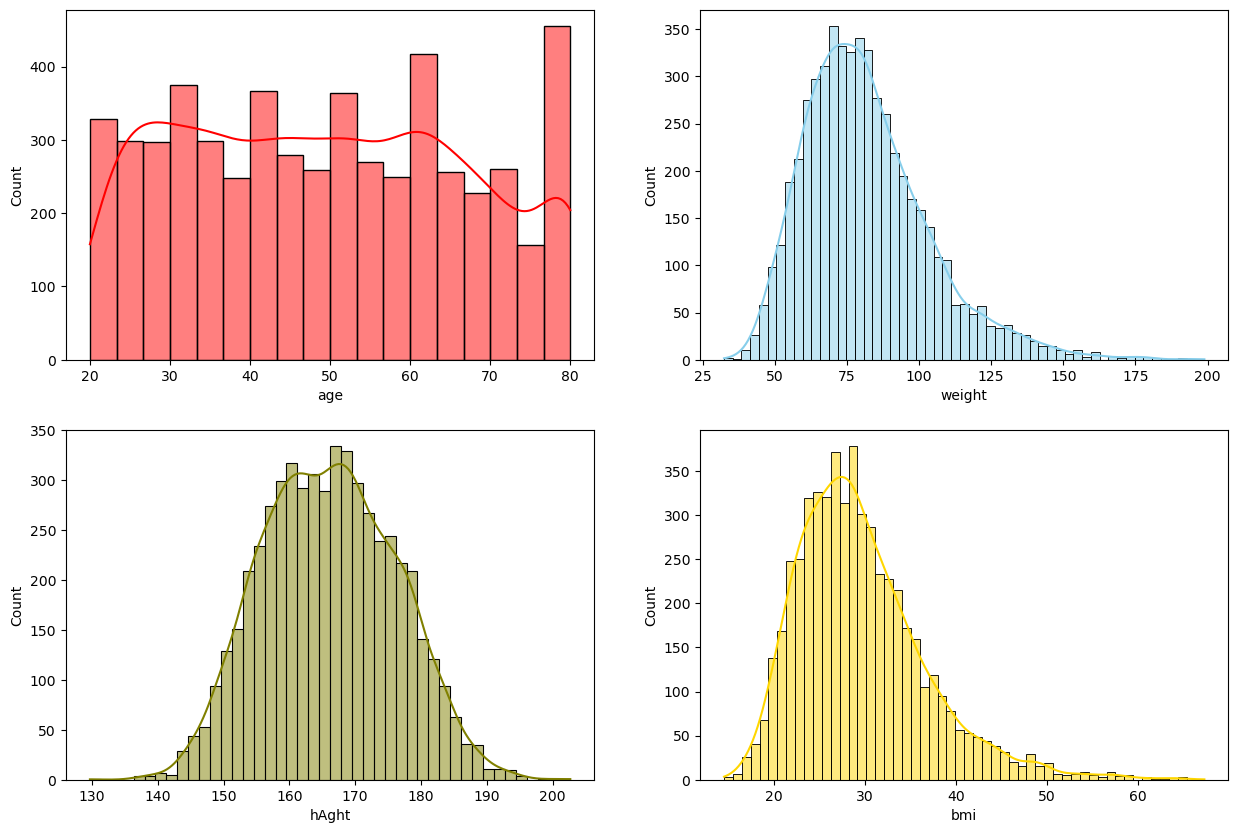

In [109]:
# Create histogram for numerical variable
fig, axs = plt.subplots(2,2, figsize=(15, 10))
      
sns.histplot(data= data, x="age", kde=True, color="red", ax=axs[0,0])
sns.histplot(data= data, x="weight", kde=True, color="skyblue", ax=axs[0,1])
sns.histplot(data= data, x="hAght", kde=True, color="olive", ax=axs[1,0])
sns.histplot(data= data, x="bmi", kde=True, color="gold", ax=axs[1,1])

plt.show()

<Axes: ylabel='bmi'>

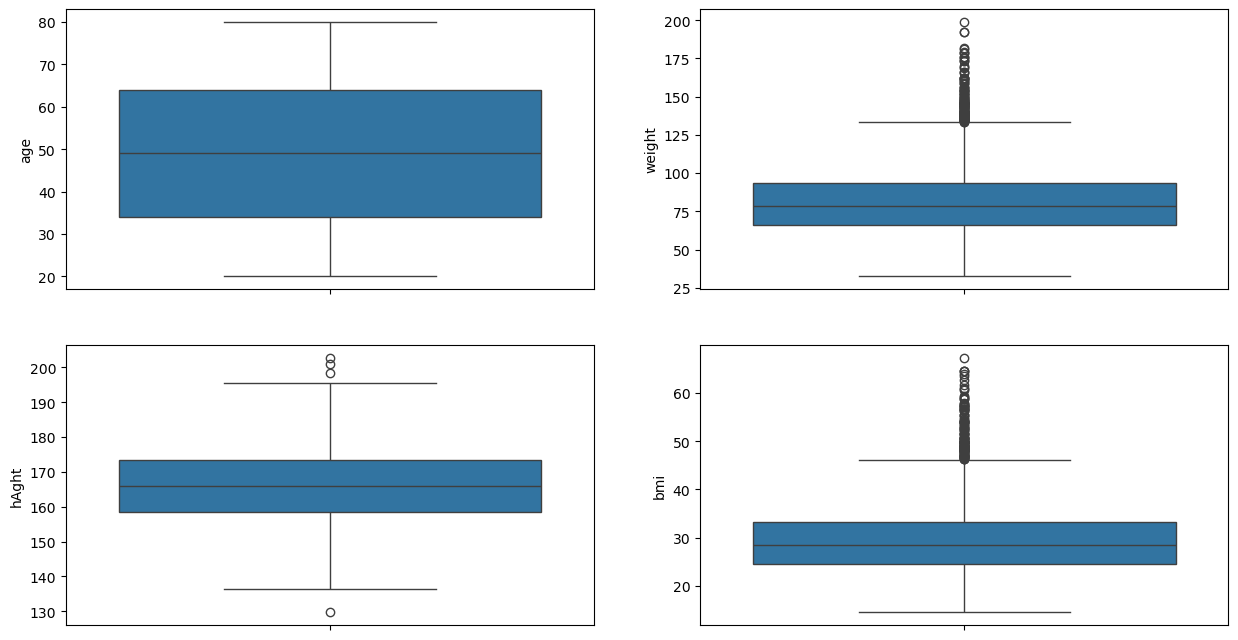

In [110]:
# Create boxplot to observe distribution of numerical value
fig, axs = plt.subplots(2,2, figsize=(15,8))
sns.boxplot(data['age'], ax = axs[0,0])
sns.boxplot(data['weight'], ax = axs[0,1])
sns.boxplot(data['hAght'], ax = axs[1,0])
sns.boxplot(data['bmi'], ax = axs[1,1])

In [111]:
# Height
qh25, qh50, qh75 = np.percentile(data['hAght'], [25,50,75])
iqrh = qh75-qh25
minh = qh25 - 1.5*iqrh
maxh = qh75 + 1.5*iqrh

#Choose the data inside IQR
data = data[(data['hAght'] > minh) & (data['hAght'] < maxh)]

In [112]:
# Weight
qw25, qw50, qw75 = np.percentile(data['weight'], [25,50,75])
iqrw = qw75-qw25
maxw = qh75 + 1.5*iqrw

#Choose the data inside IQR (only data below the max value of weight since the data is right-skewed)
data = data[data['weight'] < maxw]

In [113]:
# BMI
qb25, qb50, qb75 = np.percentile(data['bmi'], [25,50,75])
iqrb = qb75-qb25
maxb = qb75 + 1.5*iqrb

#Choose the data inside IQR (only data below the max value of bmi since the data is right-skewed)
data = data[data['bmi'] < maxb]

In [ ]:
# Look at the data after removing outliers
data.shape

(5735, 8)

In [114]:
data

,seqn,smoking,gender,age,education,weight,hAght,bmi
0,83732,1,1,62,5.0,94.8,184.5,27.8
1,83733,1,1,53,3.0,90.4,171.4,30.8
2,83734,1,1,78,3.0,83.4,170.1,28.8
3,83735,2,2,56,5.0,109.8,160.9,42.4
4,83736,2,2,42,4.0,55.2,164.9,20.3
...,...,...,...,...,...,...,...,...
5730,93695,1,2,76,3.0,59.1,165.8,21.5
5731,93696,2,1,26,5.0,112.1,182.2,33.8
5732,93697,1,2,80,4.0,71.7,152.2,31.0
5733,93700,1,1,35,1.0,78.2,173.3,26.0
